<a href="https://colab.research.google.com/github/haru523/math-problem-similarity/blob/main/ResearchSP_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
#日本語フォントのセットアップ

!apt-get -y install fonts-ipafont-gothic > /dev/null 2>&1
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "IPAGothic"

import sympy as sp
import numpy as np
import seaborn as sns
import pandas as pd
import re
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

x, y = sp.symbols('x y')

In [14]:
def _preprocess_expr_for_sympy(expr: str) -> str:
    """
    SymPyに渡す前の統一整形関数。
    - 掛け算記号の補完 (2x → 2*x)
    - 冪乗の正規化 (^ → **)
    - 不要な空白の削除
    - 全角記号の置換
    - 変数・数字・演算子の間を安全な形式に変換
    """
    expr = str(expr)
    expr = expr.replace('−', '-').replace('：', ':').replace('÷', '/')
    expr = expr.replace('^', '**')
    expr = expr.replace('＝', '=')

    # 明示的な掛け算記号を補う
    expr = re.sub(r'(\d)([a-zA-Z])', r'\1*\2', expr)  # 2x → 2*x
    expr = re.sub(r'([a-zA-Z])(\d)', r'\1*\2', expr)  # x2 → x*2
    expr = re.sub(r'([a-zA-Z])([a-zA-Z])', r'\1*\2', expr)  # xy → x*y

    # y = 1*(5) -4 → y = 1*5 - 4 のように整形
    expr = re.sub(r'\(\s*([0-9a-zA-Z\+\-\*/]+)\s*\)', r'\1', expr)

    # スペース削除・符号整理
    expr = expr.replace('++', '+').replace('+-', '-').replace('--', '+')
    expr = re.sub(r'\s+', '', expr)

    return expr

In [15]:
#文章題を方程式に変換

import re

def text_to_equation(text):
    """
    文章問題を簡易変換して方程式っぽく返す（比・簡易文章題対応）。
    - 'ある数xに6を足すと15になる' -> 'x + 6 = 15'
    - '比 3:4 = x:8' / '3:4 = x:8' -> '3/4 = x/8'
    - その他いくつかの基本パターンを含む。
    この関数は、SymPyで解析可能な形式にする前の、中間的な数学表現文字列を生成する。
    """
    # パターンマッチングのために一部置換
    s = text.replace('−', '-').replace('：', ':').replace('、','').replace('。','').strip()

    # ----- 比のパターン: A:B = C:D または A:B = x:D など -----
    # 例: "3:4 = x:8" または "比 3:4 = x:8"
    m_ratio = re.search(r'(?:(?:比\s*)?)(\d+)\s*[:：]\s*(\d+)\s*=\s*([a-zA-Z]\w*|\?)\s*[:：]\s*(\d+)', s)
    if m_ratio:
        a,b,c,d = m_ratio.groups()
        return f"{a}/{b} = {c}/{d}"

    # より一般的な比の双方が数字/式のパターン: A:B = C:D (both numeric or var)
    m_ratio2 = re.search(r'(\S+)\s*[:：]\s*(\S+)\s*=\s*(\S+)\s*[:：]\s*(\S+)', s)
    if m_ratio2:
        p,q,r,t = m_ratio2.groups()
        return f"{p}/{q} = {r}/{t}"

    # ----- 単純な文章題パターン（既存） -----
    # ある数xにAを足すとBになる
    m = re.search(r'ある数(?:x)?に\s*([0-9]+)\s*を足すと\s*([0-9]+)\s*に', s)
    if m:
        return f"x + {m.group(1)} = {m.group(2)}"

    # ある数xからAを引くとBになる
    m = re.search(r'ある数(?:x)?から\s*([0-9]+)\s*を引くと\s*([0-9]+)\s*に', s)
    if m:
        return f"x - {m.group(1)} = {m.group(2)}"

    # ある数xのA倍はBである
    m = re.search(r'ある数(?:x)?の\s*([0-9]+)\s*倍は\s*([0-9]+)', s)
    if m:
        return f"{m.group(1)}*x = {m.group(2)}"

    # A倍からBを引くとCになる
    m = re.search(r'ある数(?:x)?の\s*([0-9]+)\s*倍から\s*([0-9]+)\s*を引くと\s*([0-9]+)\s*に', s)
    if m:
        return f"{m.group(1)}*x - {m.group(2)} = {m.group(3)}"

    # そのほか、すでに等式が書かれていればそのまま返す
    if '=' in s or ':' in s:
        return s

    # マッチしないときは元の文字列を返す
    return s


def linear_function_to_equation(text):
    """
    一次関数文章（y = ax + b の記述）を方程式に変換する。
    - y = ax + b, y = N のとき -> 'N = a*x + b'
    - y = ax + b, x = N のとき -> 'y = a*N + b'
    この関数も、SymPyで解析可能な形式にする前の、中間的な数学表現文字列を生成する。
    """
    t = text.replace('−', '-').replace('：', ':') # パターンマッチングのために一部置換
    m = re.search(r'y\s*=\s*([+\-]?\d*)x\s*([+\-]?\s*\d+)?', t)
    if not m:
        return text  # 一次関数パターン以外はそのまま返す

    a_raw, b_raw = m.groups()
    a = a_raw.strip() if a_raw and a_raw.strip() != '' else '1'
    if a in ['+', '-']:
        a = a + '1'

    b = b_raw.replace(' ', '') if b_raw else '0'

    # Helper to format the b term with correct spacing and sign
    def format_b_term(b_val):
        if b_val == "0":
            return ""
        if b_val.startswith('-'):
            return f" - {b_val[1:]}" # 例: "-4" -> " - 4"
        else:
            return f" + {b_val.lstrip('+')}" # 例: "3" -> " + 3", "+3" -> " + 3"

    # --- x=指定あり --- (例: y = 2x + 3, x = 5 のとき)
    m_x = re.search(r'(?:(?:について|で|のとき).*?)x\s*=\s*([+\-]?\d+)', t)
    if m_x:
        xval = m_x.group(1)
        b_term_str = format_b_term(b)
        return f"y = {a}*{xval}{b_term_str}"

    # --- y=指定あり --- (例: y = 2x + 3, y = 9 のとき)
    m_y = re.search(r'(?:(?:について|で|のとき).*?)y\s*=\s*([+\-]?\d+)', t)
    if m_y:
        yval = m_y.group(1)
        b_term_str = format_b_term(b)
        return f"{yval} = {a}*x{b_term_str}"

    # x,y の指定がない場合は関数式自体を返す
    expr = f"y = {a}*x{format_b_term(b)}"
    return expr

In [16]:
import re

def _preprocess_expr_for_sympy(expr_str):
    """
    SymPyが解析できるように式文字列を前処理するヘルパー関数。
    - 不要な日本語を除去
    - ハイフンを標準化
    - 数字と変数間の乗算演算子を挿入 (例: '2x' -> '2*x')
    - べき乗演算子をSymPy形式に変換 (例: 'x^2' -> 'x**2')
    - その他のSymPyに不要な文字をクリーンアップ
    """
    # 日本語の問いかけ、全角記号などを置換
    expr_str = (expr_str.replace("を解け", "")
                        .replace("を求めよ", "")
                        .replace("を求めなさい", "")
                        .replace("−", "-")
                        .replace("：", ":")
                        .replace("^", "**") # べき乗を**に変換
                        .strip())

    # 数字と変数間の暗黙的な乗算を明示的にする (例: '2x' -> '2*x')
    expr_str = re.sub(r'(\d)([a-zA-Z])', r'\1*\2', expr_str)
    # 変数と数字間の暗黙的な乗算を明示的にする (例: 'x2' -> 'x*2')
    expr_str = re.sub(r'([a-zA-Z])(\d)', r'\1*\2', expr_str)
    # 変数と変数間の暗黙的な乗算を明示的にする (例: 'xy' -> 'x*y')
    expr_str = re.sub(r'([a-zA-Z])([a-zA-Z])', r'\1*\2', expr_str)

    return expr_str

In [17]:
original = "x + 10 = 12 を解け"

generated = [
    "x − 3 = 5 を解け",
    "2x + 4 = 10 を解け",
    "3x + 2 = 11 を解け",
    "一次関数 y = x − 4 について、x = 5 のときの y を求めよ",
    "一次関数 y = 2x + 3 について、y = 9 のときの x を求めよ",
    "一次関数 y = 3x + 5 について、y = 10 のときの x を求めよ",
    "x^2 + 3x + 2 = 0 を解け",
    "2x^2 + 4x + 4 = 0 を解け",
    "3x^2 + 6x - 9 = 0 を解け",
    "ある数xに6を足すと15になる。この数xを求めよ",
    "ある数xに8を足すと27になる。この数xを求めよ",
    "ある数xに12を足すと15になる。この数xを求めよ",
    "比 3:4 = x:8 のときの x を求めよ",
    "比 2:9 = x:27 のときの x を求めよ",
    "比 5:6 = x:31 のときの x を求めよ"
]

In [18]:
# Step 1: 文章 → 一般的な方程式（text_to_equation）
original = text_to_equation(original)
generated = [text_to_equation(g) for g in generated]

# Step 2: 特に一次関数の文章を処理
original = linear_function_to_equation(original)
generated = [linear_function_to_equation(g) for g in generated]

In [19]:
#方程式を解く

import sympy as sp
from sympy import symbols, Eq

# Assuming x, y are defined globally (e.g., in the first cell)
x, y = symbols('x y')

def solve_equation(expr):
    # _preprocess_expr_for_sympy を適用してSymPyが解析できる形式に変換
    processed_expr = _preprocess_expr_for_sympy(expr)

    if "=" not in processed_expr:
        try:
            parsed = sp.sympify(processed_expr)
            if parsed.free_symbols == set():
                return parsed.evalf() # 変数を含まない場合は評価
            return None # 変数を含むが等号がない場合は解決不可
        except:
            return None # 解析失敗

    # 等号で左右に分割し、それぞれをSymPy式に変換
    lhs_str, rhs_str = [s.strip() for s in processed_expr.split("=")]
    try:
        lhs = sp.sympify(lhs_str)
        rhs = sp.sympify(rhs_str)
    except:
        return None # 左右どちらかの解析失敗

    eq = sp.Eq(lhs, rhs)
    unknowns = eq.free_symbols

    # 解く変数を特定
    if x in unknowns:
        return sp.solve(eq, x)
    if y in unknowns:
        return sp.solve(eq, y)
    return None # 解くべき変数が特定できない場合

In [20]:
#AST（構文木）の特徴量抽出

def extract_ast_features(expr):
    try:
        expr = sp.simplify(expr)
    except:
        return Counter()

    features = Counter()

    def traverse(node, depth=0):
        features[f"type:{type(node).__name__}"] += 1
        features[f"depth:{depth}"] += 1
        for arg in getattr(node, "args", []):
            traverse(arg, depth+1)

    traverse(expr)
    return features

In [21]:
#多項式＋変数＋項構造の統合特徴量

import sympy as sp
from collections import Counter

# Assuming x, y symbols are globally defined

def extract_unified_structure(expr_str):
    """
    左右差分 f = lhs - rhs の構造を統合ベクトル化
    - 多項式次数
    - 係数
    - AST構造
    - 項の数
    - 変数の種類
    """
    features = Counter()

    # _preprocess_expr_for_sympy を適用してSymPyが解析できる形式に変換
    processed_expr_str = _preprocess_expr_for_sympy(expr_str)

    if "=" in processed_expr_str:
        lhs_str, rhs_str = processed_expr_str.split("=")
        try:
            # SymPy式に変換し、左右の差分を取る
            # ここではsp.simplifyではなくsp.sympifyを使用し、直接の文字列解析を行う
            lhs = sp.sympify(lhs_str.strip())
            rhs = sp.sympify(rhs_str.strip())
            f = lhs - rhs
        except:
            # 解析失敗した場合は、左辺のみを試すか、空のCounterを返す
            try:
                f = sp.sympify(lhs_str.strip())
            except:
                return Counter() # 両方失敗した場合は空のCounterを返す
    else:
        try:
            # 等号がない場合は全体を一つの式として解析
            f = sp.sympify(processed_expr_str)
        except:
            return Counter() # 解析失敗

    poly = None
    try:
        poly = sp.Poly(f) # 多項式オブジェクトを生成
    except:
        poly = None

    # --- 多項式構造 ---
    if poly:
        features["poly_degree"] = poly.degree() # 次数
        coeffs = poly.all_coeffs() # 係数
        for i, c in enumerate(coeffs):
            features[f"poly_coeff_{i}"] = float(c)

    # --- 変数 ---
    for v in f.free_symbols:
        features[f"var:{v}"] += 1 # 含まれる変数

    # --- 項数 ---
    expanded = sp.expand(f) # 式を展開して項数をカウント
    if hasattr(expanded, "args"):
        features["term_count"] = len(expanded.args)

    # --- AST ---
    ast_feat = extract_ast_features(f) # ASTに基づく特徴量
    features.update(ast_feat)

    return features

In [22]:
#ベクトル化 & 類似度

def to_vector(counter, feature_list):
    return np.array([counter.get(f, 0) for f in feature_list])

def unified_similarity(e1, e2, feature_list):
    v1 = to_vector(extract_unified_structure(e1), feature_list)
    v2 = to_vector(extract_unified_structure(e2), feature_list)
    if np.all(v1 == 0) or np.all(v2 == 0):
        return 0.0
    return cosine_similarity([v1], [v2])[0][0]

In [23]:
#ヒートマップ作成

def make_heatmap(all_expr, sim_func, title):
    n = len(all_expr)

    # 特徴一覧（AST + polynomial + variable）
    feature_set = set()
    for expr in all_expr:
        feature_set |= set(extract_unified_structure(expr).keys())
    feature_list = sorted(list(feature_set))

    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            matrix[i][j] = sim_func(all_expr[i], all_expr[j], feature_list)

    df = pd.DataFrame(matrix, index=all_expr, columns=all_expr)

    plt.figure(figsize=(12, 10))
    sns.heatmap(df, cmap="coolwarm", annot=False, vmin=0, vmax=1)
    plt.title(title)
    plt.show()

    return df

In [24]:
#original,generatedに適用

original = "x + 10 = 12 を解け"

generated = [
    "x − 3 = 5 を解け",
    "2x + 4 = 10 を解け",
    "3x + 2 = 11 を解け",
    "一次関数 y = x − 4 について、x = 5 のときの y を求めよ",
    "一次関数 y = 2x + 3 について、y = 9 のときの x を求めよ",
    "一次関数 y = 3x + 5 について、y = 10 のときの x を求めよ",
    "x^2 + 3x + 2 = 0 を解け",
    "2x^2 + 4x + 4 = 0 を解け",
    "3x^2 + 6x - 9 = 0 を解け",
    "ある数xに6を足すと15になる。この数xを求めよ",
    "ある数xに8を足すと27になる。この数xを求めよ",
    "ある数xに12を足すと15になる。この数xを求めよ",
    "比 3:4 = x:8 のときの x を求めよ",
    "比 2:9 = x:27 のときの x を求めよ",
    "比 5:6 = x:31 のときの x を求めよ"
]

# ---- 文章 → 式変換 ----
original = linear_function_to_equation(text_to_equation(original))
generated = [linear_function_to_equation(text_to_equation(g)) for g in generated]


print("元問題:", original)
print("生成問題:", generated)
print("元の解:", solve_equation(original))
print("生成問題の解:", {g: solve_equation(g) for g in generated})

元問題: x + 10 = 12 を解け
生成問題: ['x - 3 = 5 を解け', '2x + 4 = 10 を解け', '3x + 2 = 11 を解け', 'y = 1*5 - 4', '9 = 2*x + 3', '10 = 3*x + 5', 'x^2 + 3x + 2 = 0 を解け', '2x^2 + 4x + 4 = 0 を解け', '3x^2 + 6x - 9 = 0 を解け', 'x + 6 = 15', 'x + 8 = 27', 'x + 12 = 15', '3/4 = x/8', '2/9 = x/27', '5/6 = x/31']
元の解: [2]
生成問題の解: {'x - 3 = 5 を解け': [8], '2x + 4 = 10 を解け': [3], '3x + 2 = 11 を解け': [3], 'y = 1*5 - 4': [1], '9 = 2*x + 3': [3], '10 = 3*x + 5': [5/3], 'x^2 + 3x + 2 = 0 を解け': [-2, -1], '2x^2 + 4x + 4 = 0 を解け': [-1 - I, -1 + I], '3x^2 + 6x - 9 = 0 を解け': [-3, 1], 'x + 6 = 15': [9], 'x + 8 = 27': [19], 'x + 12 = 15': [3], '3/4 = x/8': [6], '2/9 = x/27': [6], '5/6 = x/31': [155/6]}


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 12369 (\N{HIRAGANA LETTER KE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25913 (\N{CJK UNIFIED IDEOGRAPH-6539}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: 

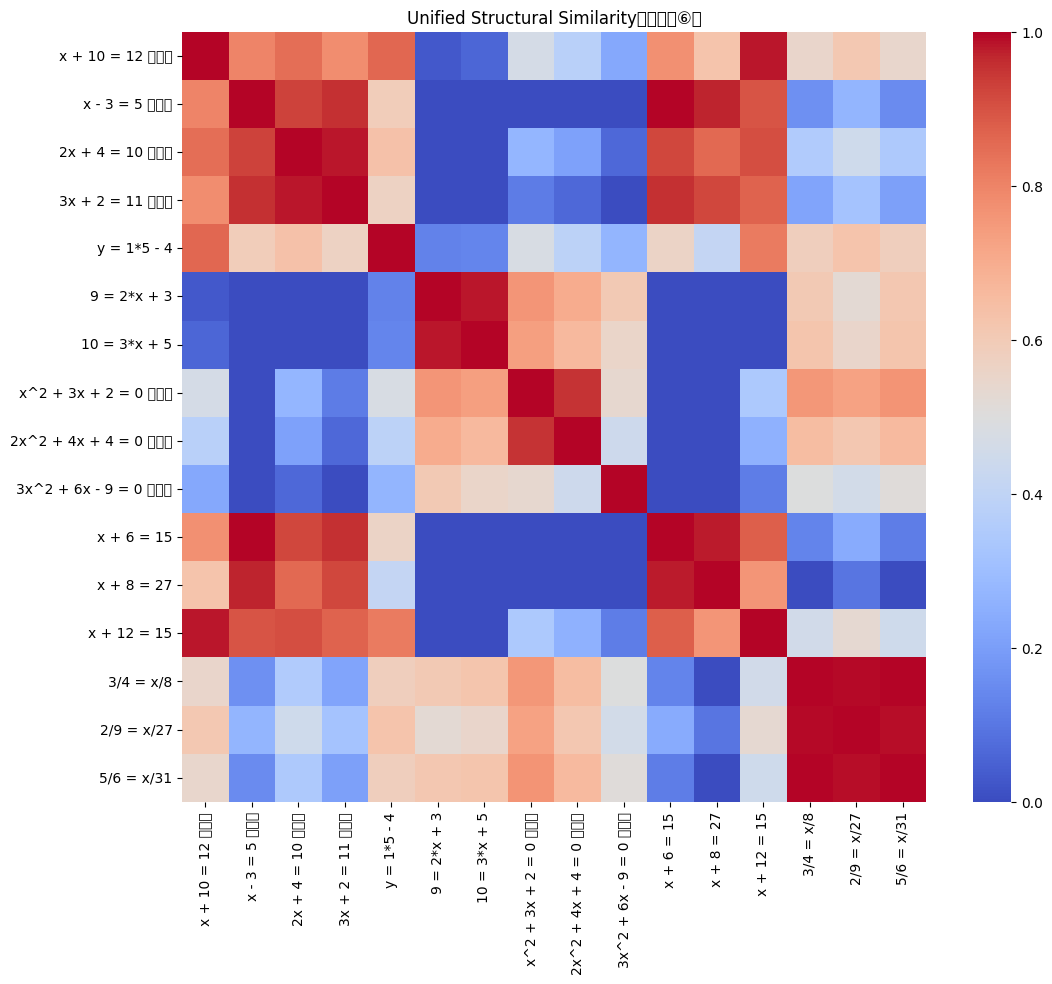

In [25]:
#ヒートマップ（改善案⑥の統合構造類似度）

all_expr = [original] + generated
df_unified = make_heatmap(all_expr, unified_similarity, "Unified Structural Similarity（改善案⑥）")